<a href="https://colab.research.google.com/github/olga-horbunova91/python-analytics-homework/blob/main/Horbunova_python-developer-survey-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# основні дані
survey = pd.read_csv("survey_results_public.csv")

# схема з описом питань
schema = pd.read_csv("survey_results_schema.csv")


In [ ]:
total_respondents = survey.shape[0]
total_respondents

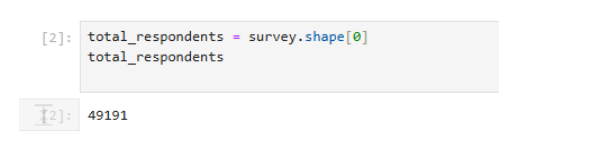

In [ ]:
questions = set(schema["qname"])

In [ ]:
survey_questions = questions.intersection(survey.columns)
len(survey_questions)


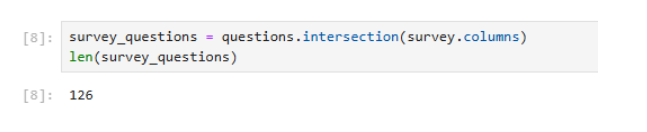

In [ ]:
answered_all = survey[list(survey_questions)].notna().all(axis=1).sum()
answered_all

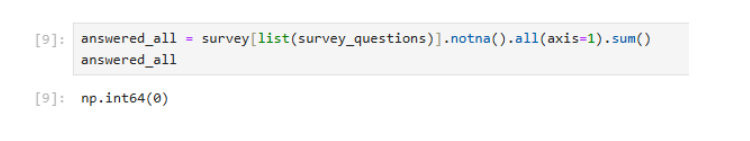

In [ ]:
workexp = survey["WorkExp"]

stats = {
    "mean": workexp.mean(),
    "median": workexp.median(),
    "mode": workexp.mode().iloc[0]
}

pd.Series(stats)

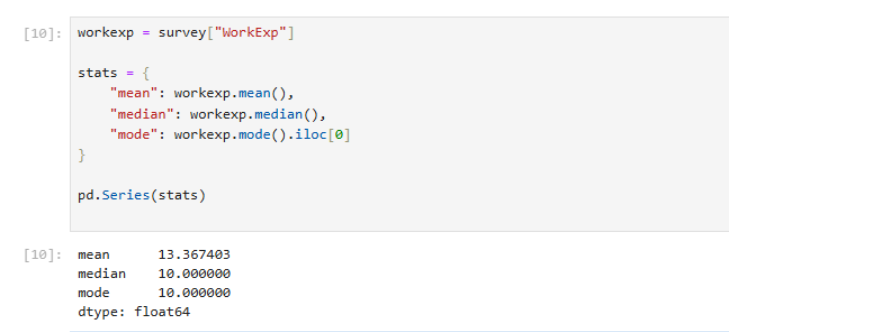

In [ ]:
survey["RemoteWork"].value_counts()

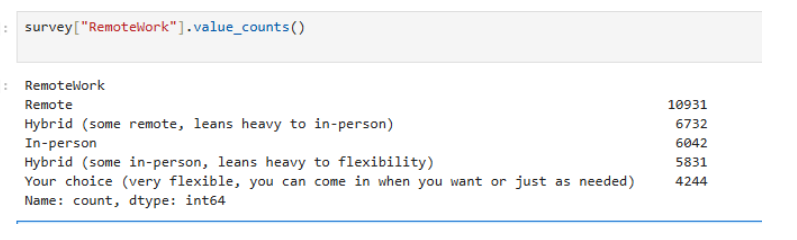

In [ ]:
remote_count = survey[survey["RemoteWork"] == "Remote"].shape[0]
remote_count


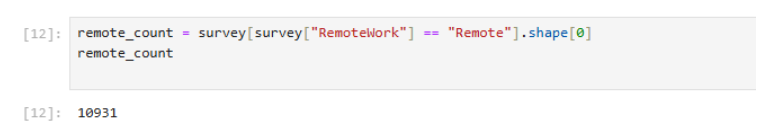

In [ ]:
python_users = survey["LanguageHaveWorkedWith"].str.contains("Python", na=False)
python_percentage = python_users.mean() * 100

round(python_percentage, 2)

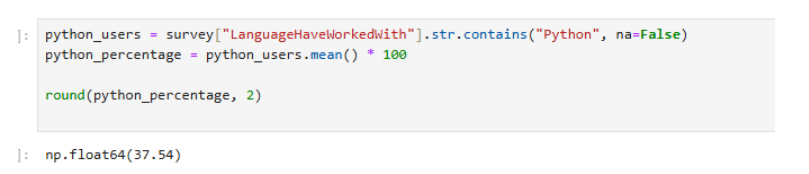

In [ ]:
survey['LearnCode'].head()

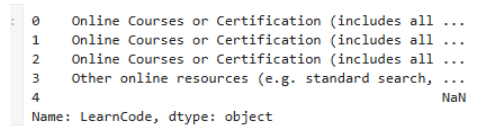

In [ ]:
# фільтруємо тих, хто обрав онлайн-курси
online_learners = survey[
    survey['LearnCode'].notna() &
    survey['LearnCode'].str.contains('Online Courses', case=False)
]

# кількість таких респондентів
online_learners_count = online_learners.shape[0]
online_learners_count

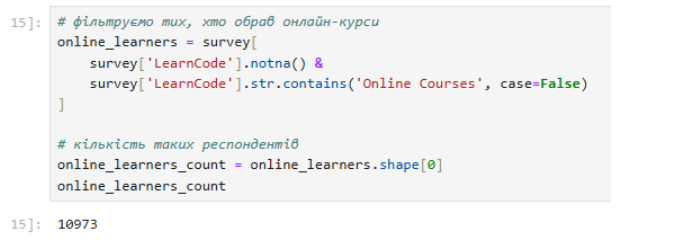

In [ ]:
python_devs = survey[
    survey['LanguageHaveWorkedWith'].notna() &
    survey['LanguageHaveWorkedWith'].str.contains('Python')
]

comp_by_country = (
    python_devs
    .dropna(subset=['ConvertedCompYearly', 'Country'])
    .groupby('Country')['ConvertedCompYearly']
    .agg(
        average_compensation='mean',
        median_compensation='median'
    )
    .reset_index()
)

comp_by_country.head()

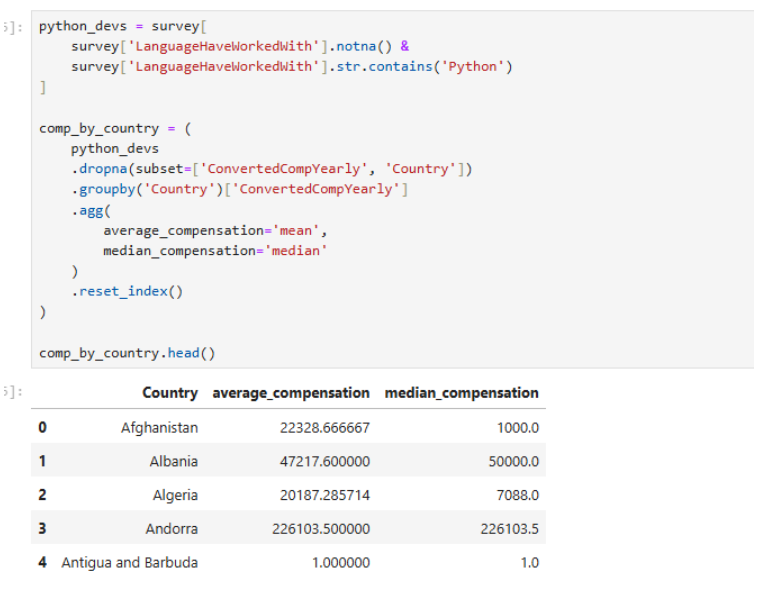

In [ ]:
top_5_paid = (
    survey
    .dropna(subset=['ConvertedCompYearly', 'EdLevel'])
    .sort_values(by='ConvertedCompYearly', ascending=False)
    .head(5)
)

top_5_paid[['ConvertedCompYearly', 'EdLevel']]

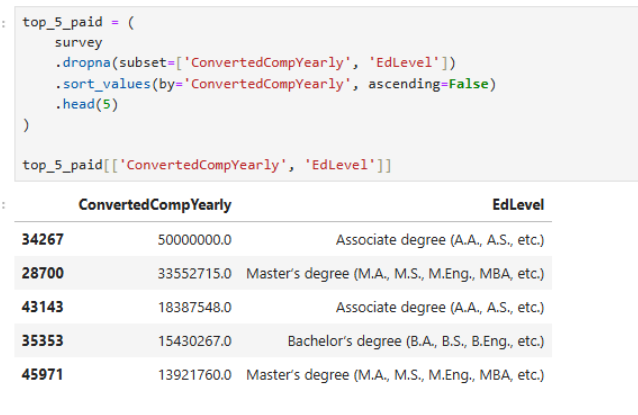

In [ ]:
# залишаємо лише респондентів з віком
age_data = survey.dropna(subset=['Age'])

# ознака: чи працює з Python
age_data['UsesPython'] = age_data['LanguageHaveWorkedWith'].str.contains(
    'Python', na=False
)

# групування по вікових категоріях
python_by_age = (
    age_data
    .groupby('Age')['UsesPython']
    .mean()          # частка True
    .mul(100)        # у відсотках
    .round(2)
    .reset_index()
    .rename(columns={'UsesPython': 'Python_Users_Percentage'})
)

python_by_age

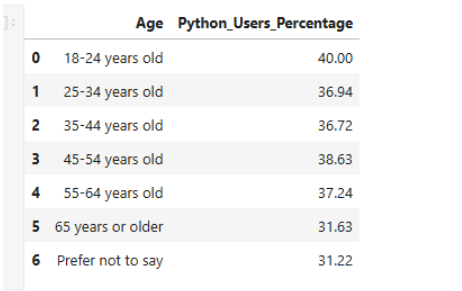

In [ ]:
# 75 перцентиль компенсації
percentile_75 = survey['ConvertedCompYearly'].quantile(0.75)

# фільтр: висока компенсація + віддалена робота
high_paid_remote = survey[
    (survey['ConvertedCompYearly'] >= percentile_75) &
    (survey['RemoteWork'] == 'Remote') &
    (survey['Industry'].notna())
]

# підрахунок індустрій
top_industries = (
    high_paid_remote['Industry']
    .value_counts()
    .reset_index()
)

top_industries.columns = ['Industry', 'Count']

top_industries

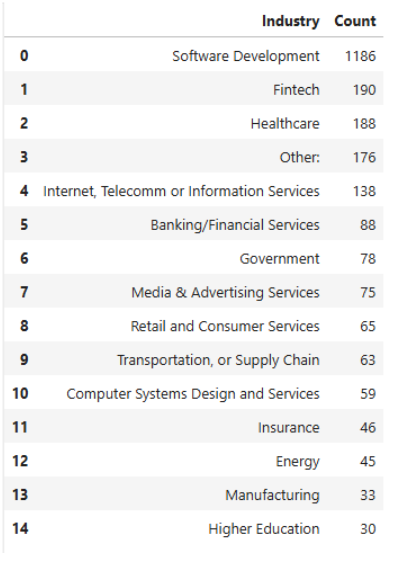